# BayesFlow: Personwise Model Comparison (Food)

Author:      David Izydorczyk 

Reminder: Install new packages with `python3.11 -m pip install package`  | active environemnt `.\personwise_BF\Scripts\activate`

In [1]:
import numpy as np
import numpy.random as rng


import matplotlib.pyplot as plt
import seaborn as sns


import os
if "KERAS_BACKEND" not in os.environ:
    # set this to "torch", "tensorflow", or "jax"
    os.environ["KERAS_BACKEND"] = "jax"

import keras
import bayesflow as bf
import pandas as pd
import statsmodels.formula.api as sm



from plotnine import (
    theme_set,
    theme_bw
)
theme_set(theme_bw())


INFO:bayesflow:Using backend 'jax'


In [2]:
import utils.helper_functions as fn
import utils.model_functions as mf

# makes sure mf is loaded correctly
import importlib
importlib.reload(mf) 
importlib.reload(fn) 

<module 'utils.helper_functions' from 'c:\\Users\\dizydorc\\OneDrive\\University\\Project Github Repositories\\Estimation processes in real-world domains\\Scripts\\Model Comparison\\utils\\helper_functions.py'>

In [3]:
# avoid scientific notation for outputs
np.set_printoptions(suppress=True)

# 1 Load Design Data 

In [4]:
df = pd.read_csv('..\..\Materials\design_data_food.csv', sep=';',decimal=",")
df.head()

,ID,item,crit,img,training,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14
0,1,Spaghetti,28,Bild1.png,1,-0.148571,0.312328,-0.253184,-0.033504,0.206118,0.081758,0.374378,-0.039376,-0.167934,-0.249604,0.267812,-0.131656,-0.057344,-0.068979
1,2,Rice,28,Bild2.png,0,-0.126647,0.350038,-0.322393,0.069598,0.081543,0.278185,0.201112,0.129577,-0.154524,-0.010257,0.004444,0.133106,0.179552,-0.027465
2,3,Rigatoni,34,Bild3.png,0,-0.156796,0.285360,-0.228005,-0.078550,0.263222,0.090086,0.456426,-0.130174,-0.055453,-0.041144,0.254142,-0.088458,-0.063824,-0.103791
3,4,Bread roll,44,Bild4.png,0,-0.311658,0.200381,-0.318327,-0.282194,0.190952,-0.080747,-0.229170,0.117601,0.063906,-0.044216,-0.130283,0.067842,-0.166336,-0.057764
4,5,Oat flakes,60,Bild5.png,1,-0.191199,0.167452,-0.357693,-0.042401,0.047376,0.399785,-0.157332,0.180173,0.089512,0.078008,0.119148,-0.014643,0.153325,-0.153469


In [5]:
all_cues = df[[f'V{i}' for i in range(1, 15)]].to_numpy(dtype=float)
all_crit = df[['crit']].to_numpy(dtype=float).flatten()

# Get Exemplar Set 
exemplars = df.loc[df['training'] == 1,:] 
ex_cues   = exemplars[[f'V{i}' for i in range(1, 15)]].to_numpy(dtype=float)
ex_crit   = exemplars[['crit']].to_numpy(dtype=float).flatten()
ex_IDs    = exemplars[["ID"]].to_numpy(dtype=float).squeeze().astype(int)

# Get Data from only Testing items
testing = df.loc[df['training'] == 0,:]

# Get the IDs
test_IDs = testing[["ID"]].to_numpy(dtype=float).squeeze().astype(int)

# Extract cues of the testing stimuli
cues     = testing[[f'V{i}' for i in range(1, 15)]].to_numpy(dtype=float)

# Make cue dictionary
dict_cues = {f"cue_{i}": cues[:, i] for i in range(cues.shape[1])}

# Geet number of trials and number of dimensions
n_trials, n_dim     = cues.shape

print("n_trials:", n_trials)
print("n_dim:"   , n_dim)

n_trials: 68
n_dim: 14


In [6]:
# Set general parameters
rate = 0.25

In [7]:
# Define positional encodings
position_encodings = np.linspace(0, 1, n_trials, dtype=np.float32)

# 2 Define Models

## 2.1 CAM - Cue Abstraction (Rule) Model 

In [8]:
# Run Regression on whole item samples
result = sm.ols(formula="crit ~ V1 + V2 + V3 + V4 + V5 + V6 + V7 + V8 + V9 + V10 + V11 + V12 + V13 + V14", data=df).fit()
# print(result.params)
# print(result.summary())

In [9]:
def prior_CAM(n_dim = n_dim, rate = rate):

    # Init weight parameters
    w = np.zeros(n_dim+1)

    # Intercept
    w[0]   = rng.normal(21.7, 20)

    # Dimension weights (Importance)
    w[1:]  = rng.normal(0, 25, size = n_dim)

    sigma  = rng.exponential(1/rate)

    return dict(w=w, sigma=sigma)

In [10]:
def model_CAM(w, sigma, cues=cues, p=position_encodings):

    n_trials, _   = cues.shape
  
    # Pre-allocate the output matrix
    pred_crit = mf.CAM_experiment(w,cues)

    # Simulate responses 
    x = fn.truncnorm_r(mean=pred_crit, sd=sigma, low=0, upp=100, size=n_trials)
    
    return dict(x=x, p=p)  


In [11]:
simulator_CAM = bf.make_simulator([prior_CAM, model_CAM])

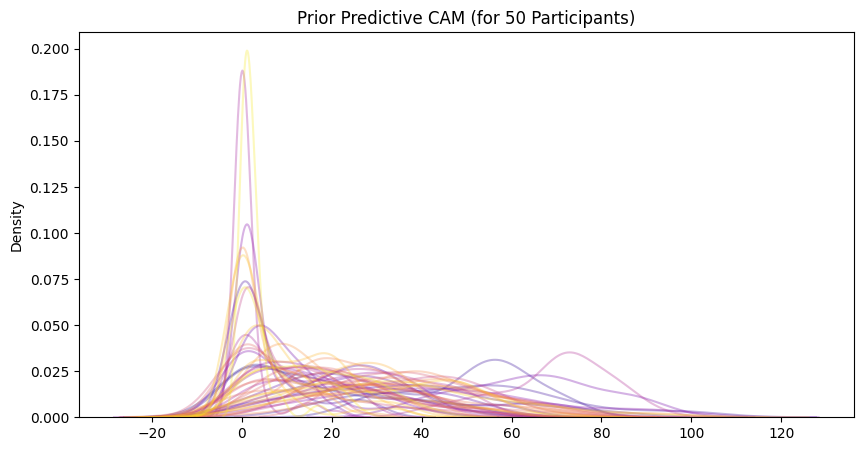

In [12]:
fig, ax = fn.plot_prior_predictives(simulator_CAM, "CAM")

## 2.2 GCM - Exemplar Model

In [13]:
def prior_GCM(n_dim = n_dim, rate = rate):

    c      = rng.exponential(1/0.1)
    w      = rng.dirichlet(np.ones(n_dim), size = 1)*n_dim 
    sigma  = rng.exponential(1/rate)

    return dict(c=c, w=w.squeeze(), sigma=sigma)

In [14]:
def model_GCM(c, w, sigma, cues=cues, ex_cues=ex_cues, ex_crit=ex_crit, p=position_encodings):
  
    n_trials = cues.shape[0]

    # Make predictions based on the GCM model for all trials at once
    pred_crit = mf.GCM_experiment(cues, ex_cues, ex_crit, w, c)

    # Simulate responses
    x = fn.truncnorm_r(mean=pred_crit, sd=sigma, low=0, upp=100, size=n_trials)

    return dict(x=x,p=p) 

In [15]:
simulator_GCM = bf.make_simulator([prior_GCM, model_GCM])

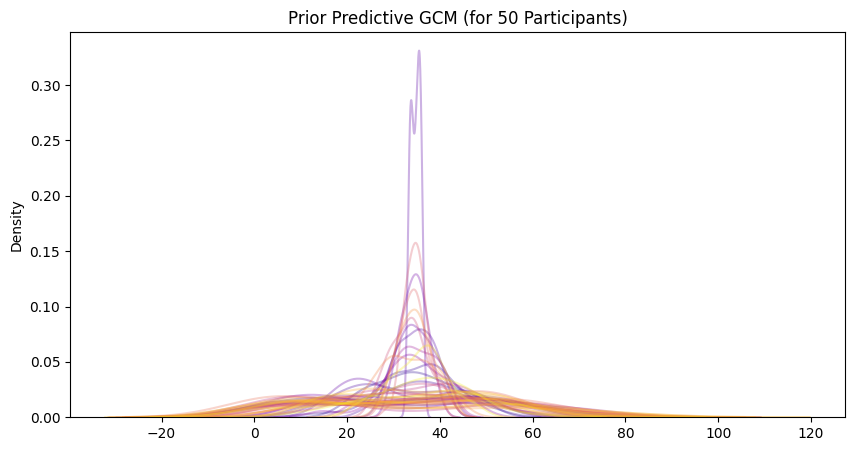

In [16]:
fig, ax = fn.plot_prior_predictives(simulator_GCM, "GCM")

## 2.3 RulExJ Model


In [17]:
def prior_RULEXJ(n_dim = n_dim, rate = rate):

    # Rule part
    CAM_pars = prior_CAM(n_dim = n_dim, rate = rate)

    # Exemplar part
    GCM_pars = prior_GCM(n_dim = n_dim, rate = rate)

    # Blending
    a        = rng.uniform(0,1)

    return dict(alpha = a, w_CAM=CAM_pars["w"], c = GCM_pars["c"], w_GCM = GCM_pars["w"], sigma=CAM_pars["sigma"])

In [18]:
def model_RULEXJ(alpha, w_CAM, c, w_GCM, sigma,  cues=cues, ex_cues=ex_cues, ex_crit=ex_crit, p=position_encodings):
    
    n_trials, _   = cues.shape
    
    pred_CAM = mf.CAM_experiment(w_CAM,cues)

    pred_GCM = mf.GCM_experiment(cues, ex_cues, ex_crit,w_GCM,c)

    pred_RULEXJ = alpha*pred_CAM + (1-alpha)*pred_GCM

    # Simulate responses 
    x = fn.truncnorm_r(mean=pred_RULEXJ, sd=sigma, low=0, upp=100, size=n_trials)

    return dict(x=x, p=p)

In [19]:
simulator_RULEXJ = bf.make_simulator([prior_RULEXJ, model_RULEXJ])

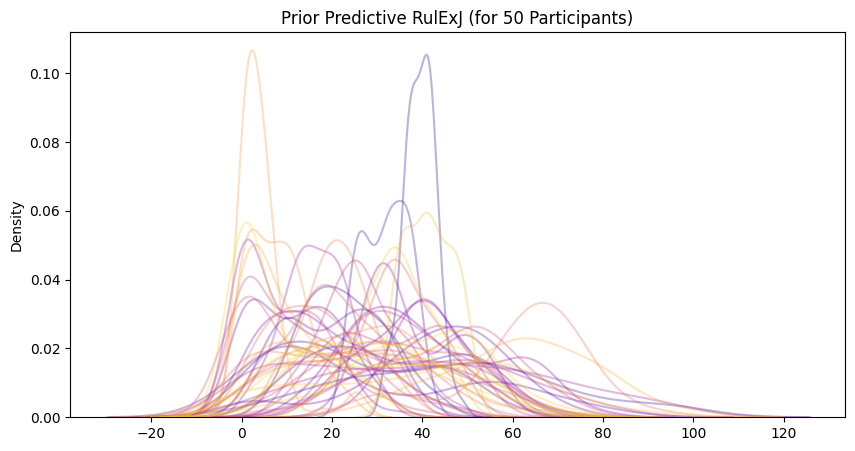

In [20]:
fig, ax = fn.plot_prior_predictives(simulator_RULEXJ, "RulExJ")

## 2.4 Mapping Model (MAPP)

For the mapping model, the direction of the cues have to coded so that each cue (i.e., dimension) has a positive relationship with the criterion.

In [21]:
# Change cue direction and redefine exemplar and stimuli cues for the mapping model
all_mapp_cues  = mf.preprocess_cues(all_cues,all_crit)
ex_mapp_cues   = all_mapp_cues[ex_IDs-1,:]
mapp_cues      = all_mapp_cues[test_IDs-1,:]
dict_mapp_cues = {f"cue_{i}": mapp_cues[:, i] for i in range(mapp_cues.shape[1])}

In [22]:
def prior_MAPP(lower = 2, upper = 12, rate = rate):

    n_cats = fn.truncated_poisson_np(5, lower = lower, upper = upper)
    sigma  = rng.exponential(1/rate)
    
    return  dict(n_cats=n_cats[0], sigma=sigma)

In [23]:
def model_MAPP(n_cats, sigma, cues=mapp_cues,ex_cues=ex_mapp_cues, ex_crit=ex_crit, p=position_encodings):

    n_trials, _   =  cues.shape 

    # Make predictions based on the GCM model for each person
    pred_crit = mf.MAPP_experiment(n_cats,cues,ex_cues,ex_crit)

    # Simulate responses 
    x = fn.truncnorm_r(mean=pred_crit, sd=sigma, low=0, upp=100, size=n_trials)
  

    return dict(x=x, p=p)

In [24]:
simulator_MAPP = bf.make_simulator([prior_MAPP, model_MAPP])

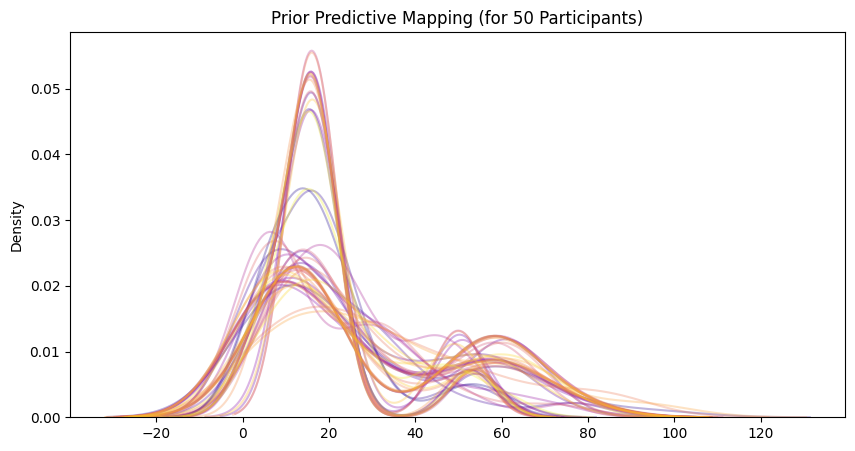

In [25]:
fig, ax = fn.plot_prior_predictives(simulator_MAPP, "Mapping")

## 2.5 QuickEst

For the QuickEst-Model, the direction of the cues have to coded so that each cue (i.e., dimension) has a positive relationship with the criterion. Also the cues need to binary.

In [26]:
# Change cue direction and redefine exemplar and stimuli cues for the QuickEst model
all_QEst_cues  = mf.preprocess_cues_QuickEst(all_cues,all_crit)
ex_QEst_cues   = all_QEst_cues[ex_IDs-1,:]
QEst_cues      = all_QEst_cues[test_IDs-1,:]
dict_QEst_cues = {f"cue_{i}": QEst_cues[:, i] for i in range(QEst_cues.shape[1])}

In [27]:
def prior_QEst():

    sigma = fn.truncated_cauchy_np(loc=0, scale=10, lower=0.001, upper=100, size=1)

    return dict(sigma=sigma)

In [28]:
def model_QEst(sigma,  cues = QEst_cues, ex_cues = ex_QEst_cues, ex_crit = ex_crit, p=position_encodings):
 
    # Step 0: Draw "memorized" ex_crit for each participant
    mem_ex_crit = np.random.normal(ex_crit,sigma) 

    # Make predictions based on the GCM model for each person
    x = mf.QuickEst_experiment(cues,ex_cues,mem_ex_crit)
 

    return dict(x = np.clip(x, 0, 100), p=p)

In [29]:
simulator_QEst = bf.make_simulator([prior_QEst, model_QEst])

c:\Users\dizydorc\OneDrive\University\Project Github Repositories\Estimation processes in real-world domains\Scripts\Model Comparison\utils\helper_functions.py:127: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.


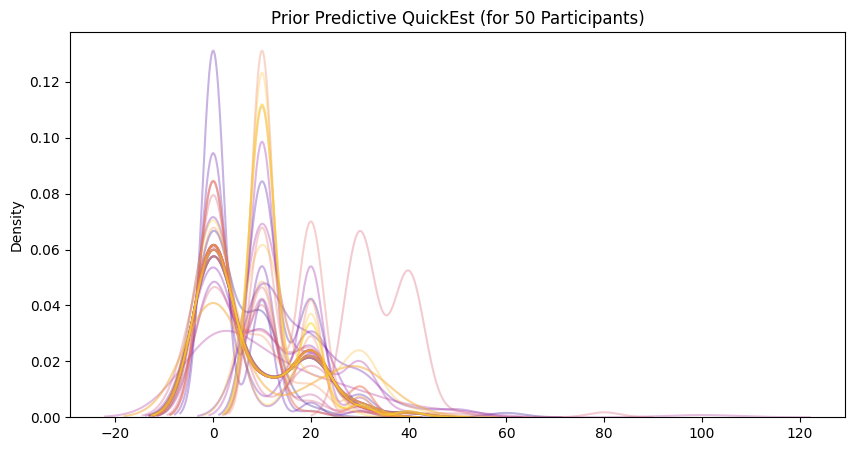

In [30]:
fig, ax = fn.plot_prior_predictives(simulator_QEst, "QuickEst")

## 2.6 RGuess - Random Guessing 

In [31]:
def prior_RGuess():

    sigma_range = rng.exponential(1/0.25, size = 1)

    return  dict(sigma_range=sigma_range)

In [32]:
def model_RGuess(sigma_range, cues = cues, ex_crit = ex_crit, p=position_encodings):

    n_trials, _   =  cues.shape 

    min_observed_crit = rng.normal(np.min(ex_crit),sigma_range)
    range_width = max(0.01, rng.normal(np.max(ex_crit) - np.min(ex_crit), sigma_range))  # enforce positive width

    max_observed_crit = min_observed_crit + abs(range_width)

    x =  rng.uniform(min_observed_crit, max_observed_crit, size = n_trials)
    
    return dict(x = np.clip(x, 0, 100), p=p)


In [33]:
simulator_RGuess = bf.make_simulator([prior_RGuess, model_RGuess])

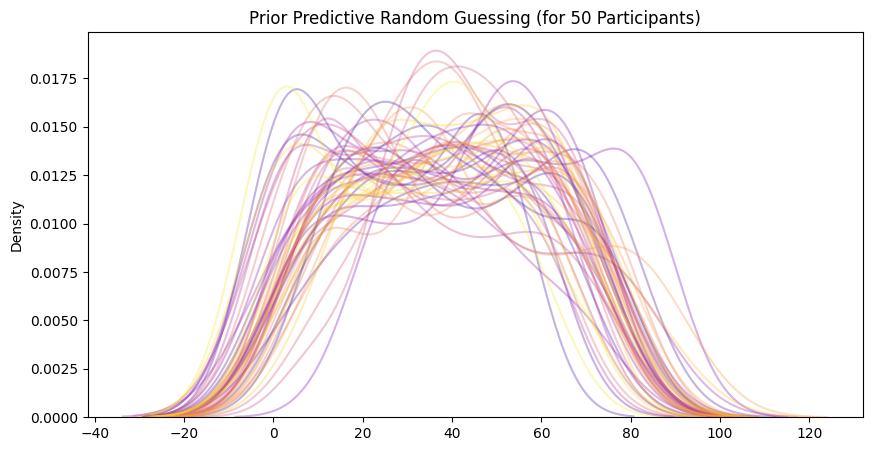

In [34]:
fig, ax = fn.plot_prior_predictives(simulator_RGuess, "Random Guessing")

# 3 Training Networks

In [35]:
simulator = bf.simulators.ModelComparisonSimulator(
    simulators        = [simulator_RULEXJ,simulator_CAM,simulator_GCM, simulator_MAPP,simulator_QEst,simulator_RGuess],
    use_mixed_batches = True
)

In [36]:
adapter = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")   
    .as_time_series(["x","p"])
    .standardize("x")
    .drop(["alpha","c","sigma","w_GCM","w_CAM","n_cats","sigma_range"])
    .concatenate(["x", "p"], into="summary_variables")
)

summary_network    = bf.networks.TimeSeriesNetwork(summary_dim=20)

classifier_network = bf.networks.MLP(widths=[256] * 32, activation="silu", dropout=None)

approximator = bf.approximators.ModelComparisonApproximator(
     num_models         = len(simulator.simulators),
     classifier_network = classifier_network,
     summary_network    = summary_network,
     adapter            = adapter,
 )

In [37]:
num_batches_per_epoch = 512
batch_size            = 64
epochs                = 100

learning_rate = keras.optimizers.schedules.CosineDecay(1e-4, decay_steps=epochs * num_batches_per_epoch)
optimizer     = keras.optimizers.Adam(learning_rate=learning_rate)
approximator.compile(optimizer=optimizer)

In [39]:
%%time

history = approximator.fit(epochs = epochs, batch_size = batch_size,  num_batches = num_batches_per_epoch, adapter = adapter, simulator = simulator)

INFO:bayesflow:Building dataset from simulator instance of ModelComparisonSimulator.
INFO:bayesflow:Using 16 data loading workers.


Epoch 1/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - loss: 0.2653 - loss/classifier_loss: 0.2653
Epoch 2/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 30s 57ms/step - loss: 0.2611 - loss/classifier_loss: 0.2611
Epoch 3/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - loss: 0.2606 - loss/classifier_loss: 0.2606
Epoch 4/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 30s 57ms/step - loss: 0.2624 - loss/classifier_loss: 0.2624
Epoch 5/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 30s 57ms/step - loss: 0.2580 - loss/classifier_loss: 0.2580
Epoch 6/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - loss: 0.2598 - loss/classifier_loss: 0.2598
Epoch 7/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - loss: 0.2488 - loss/classifier_loss: 0.2488
Epoch 8/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - loss: 0.2621 - loss/classifier_loss: 0.2621
Epoch 9/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 36s 70ms/step - loss: 0.2522 - loss/classifier_loss: 0.2522
Epoch 10/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 30s 57ms/step - loss: 0.2495 - loss/classifier_lo

In [42]:
df          = simulator.sample(10000)
pred_models = approximator.predict(conditions=df)

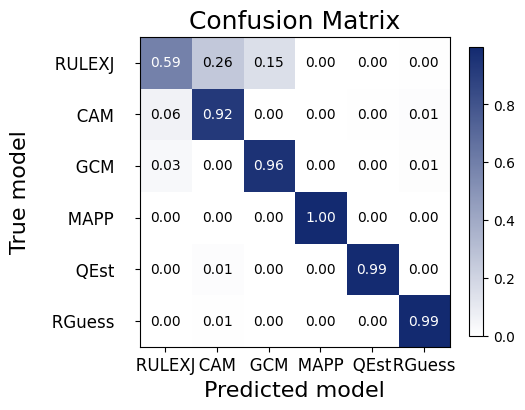

In [43]:
f=bf.diagnostics.plots.mc_confusion_matrix(
    pred_models=pred_models,
    true_models=df["model_indices"],
    normalize="true",
    model_names=["   RULEXJ   ", "   CAM   ", "   GCM   ", "   MAPP   ", "   QEst   ", "   RGuess   "]
)

In [44]:
# Save model
approximator.save("..\..\Results\Model Comparison\model_comparison_FOOD.keras")

# 4 Model Fitting per Participant

In [45]:
# Load data
df = pd.read_csv('..\..\Data\data_analysis_food.csv', sep = ",")
df.head()

,ID_item,item,img,training,crit,qza2yw7qkddd,wdqr0khtrkyu,puwl4gv8w7xv,i636fcg5x0fy,mcvs1zmkool3,...,hs7xjpxwqzoz,t7nnzue0eo9u,l8ezhyyp325m,5cib5ha5gyup,0ba3662lv6vw,ce75nokgote6,tjoc8yv4kf4o,lhm6c5m9odj9,nyo8d8p2ok0i,j4tufliz4ct6
0,1,Spaghetti,Bild1.png,1,28,28,28,28,28,28,...,28,28,28.0,28,45,28,28,28,28,28
1,2,Rice,Bild2.png,0,28,87,16,28,77,75,...,77,66,25.0,55,69,60,65,45,60,35
2,3,Rigatoni,Bild3.png,0,34,55,30,28,32,28,...,34,28,30.0,57,45,50,18,30,25,30
3,4,Bread roll,Bild4.png,0,44,45,77,40,46,66,...,60,56,30.0,45,45,30,70,60,60,60
4,5,Oat flakes,Bild5.png,1,60,60,60,60,60,60,...,28,60,60.0,60,60,60,57,60,60,60


In [46]:
# Replace the NaNs with the row means calculated across all other participants (i.e., exclude the NaN and the participant with the NaN from the mean)
# Sample: assuming df is your original DataFrame

meta_cols     = ['ID_item', 'item', 'img', 'training', 'crit']
response_cols = [col for col in df.columns if col not in meta_cols]

# Copy metadata to preserve original
meta_df   = df[meta_cols].copy()
responses = df[response_cols].copy()

# Function to replace NaNs with mean of other participants
def replace_nan_with_row_mean_except_self(row):
    for col in row.index:
        if pd.isna(row[col]):
            # Compute mean of the row excluding the NaN and this column
            other_values = row.drop(labels=col).dropna()
            if not other_values.empty:
                row[col] = other_values.mean()
    return row

# Apply the function row-wise
responses_filled = responses.apply(replace_nan_with_row_mean_except_self, axis=1)

# Combine with metadata
df_filled = pd.concat([meta_df, responses_filled], axis=1)

In [47]:
data            = df_filled.to_numpy()
data            = np.float32(data[(test_IDs-1),5:])

n_trials, n_sub = data.shape

print("n_trials:", n_trials)
print("n_dim:"   , n_dim)

n_trials: 68
n_dim: 14


## Plot data

Text(0.5, 1.0, 'Prior Predictive: Guessing (for 100 Participants)')

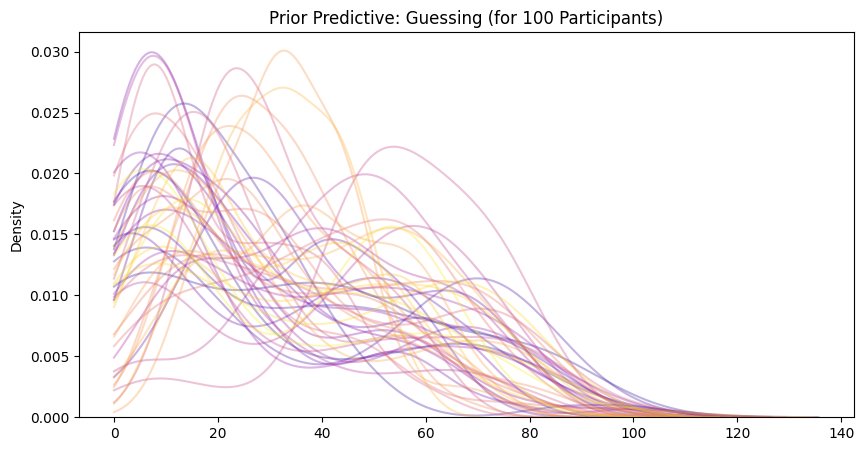

In [48]:
# Plot prior predictives
fig, axes = plt.subplots(figsize=(10, 5))
dataset_colors = sns.color_palette("plasma", n_sub).as_hex()

for dataset in range(n_sub):
    color = dataset_colors[dataset]

    sns.kdeplot(data[:,dataset].squeeze(), ax=axes, alpha=0.3, legend=False, color=color,clip=(0.0, 10000.0))
    

axes.set_title("Prior Predictive: Guessing (for 100 Participants)")

## "Fit" Models

In [ ]:
# Load model if needed
# approximator  = keras.saving.load_model("..\..\Results\Model Comparison\model_comparison_FOOD.keras")

c:\Users\dizydorc\OneDrive\University\Project Github Repositories\Estimation processes in real-world domains\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 169 variables. 


In [49]:
n_models = 6  
all_pmps = np.zeros((n_sub, n_models)) 

for i in range(n_sub):
    pmp         = approximator.predict(conditions=dict(x=data[:,i], p = position_encodings))[0]
    all_pmps[i] = pmp.flatten() 

In [50]:
# Store results
all_pmps_df  = pd.DataFrame(all_pmps)
all_pmps_df.columns = ["RULEXJ", "CAM", "GCM", "MAPP", "QEst", "RGuess"]


all_pmps_df.to_csv("..\..\Results\pmp_FOOD.csv")

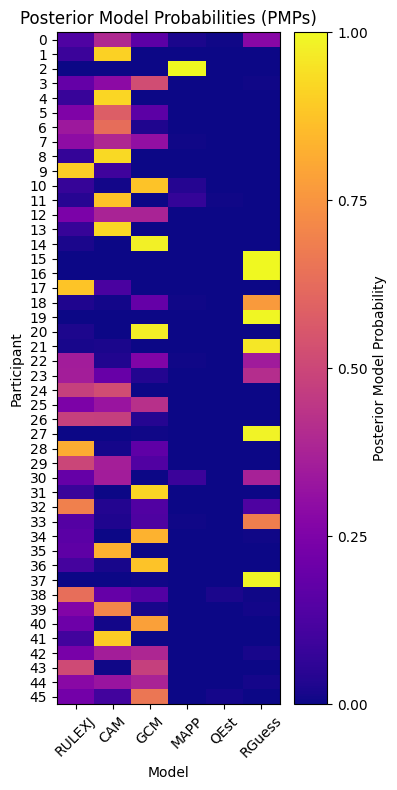

In [51]:
model_labels = ["RULEXJ", "CAM", "GCM", "MAPP", "QEst", "RGuess"]

plt.figure(figsize=(4, 8))
im = plt.imshow(all_pmps, aspect='auto', cmap='plasma', vmin=0, vmax=1)  # Fix color range

# Add colorbar with defined ticks from 0 to 1
cbar = plt.colorbar(im)
cbar.set_label('Posterior Model Probability')
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])  # Explicit tick marks

plt.xlabel('Model')
plt.ylabel('Participant')
plt.title('Posterior Model Probabilities (PMPs)')

plt.xticks(ticks=np.arange(len(model_labels)), labels=model_labels, rotation=45);
plt.yticks(ticks=np.arange(n_sub), labels=[str(i) for i in range(n_sub)]);

plt.tight_layout()
plt.show()
